In [2]:
import numpy as np
import sympy as sp
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

csv = pd.read_csv('./income.csv')
res = pd.read_csv('./weighted_refactored_income.csv')

incomes = csv['Household Income by Race']

In [3]:
x1 = res.income 
y1 = res.absolute_increase

x = []
b = []

for i, e in enumerate(x1):
    if (not pd.isna(e)) and (y1[i] > 0): 
        x.append(e)
        b.append(y1[i])

A = np.zeros((len(x), 2))


A[:, 0] = np.ones(len(x))
A[:, 1] = x

x = np.array(x)
b = np.array(b)

c, m = np.linalg.inv(A.T@A)@A.T@b

c, m

(34.38306136401037, -3.0573682958713095e-05)

In [4]:
red = '#f8766d'
blue = '#619cff'

s = sp.Symbol('s')

deltaT = c+m*s

fig = go.Figure()

fig.add_trace(
    go.Scatter(x=x, y=b,  mode='markers', marker=dict(
                        color=blue,
                    ),)
)


fig.add_trace(
    go.Scatter(x=x, y=[float(deltaT.subs(s, i)) for i in x], marker=dict(
                        color=red,
                        line=dict(color=red, width=2)
                    ),)
)

In [5]:
x = sp.Symbol('x')

shortest_path = 691.869904-0.001095*x

n_cameras = shortest_path*0.0017630

ticket_cost = 100

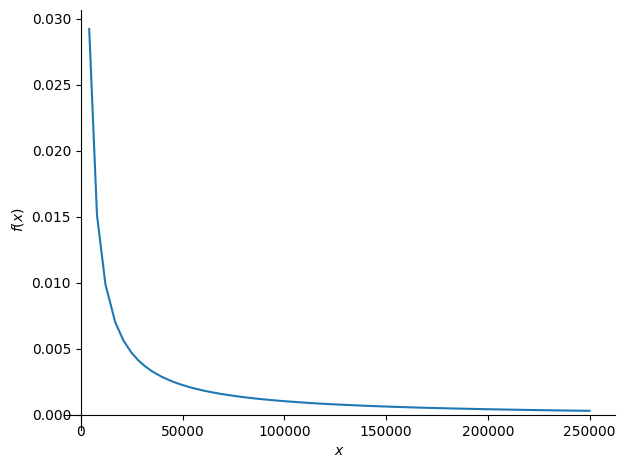

In [6]:
sp.plot(n_cameras/x*ticket_cost, (x, incomes.min(), incomes.max()))

In [7]:
xs = np.linspace(20000, 200000, int((200000-20000)/100)+1)
y = np.array([float(n_cameras.subs(x, i)/i*ticket_cost) for i in xs])

df = pd.DataFrame(0, columns=['income', 'y'], index=[i for i in range(len(xs))])

In [8]:
df.income = xs
df.y = y

df

,income,y
0,20000.0,0.005906
1,20100.0,0.005875
2,20200.0,0.005845
3,20300.0,0.005816
4,20400.0,0.005786
...,...,...
1796,199600.0,0.000418
1797,199700.0,0.000418
1798,199800.0,0.000417
1799,199900.0,0.000417


In [14]:
red = '#f8766d'
blue = '#619cff'

style_dict = {
    'layout.plot_bgcolor': 'rgba(0, 0, 0, 0)',
    'layout.font.family': 'Times New Roman',
    'layout.xaxis.linecolor': 'black',
    'layout.xaxis.ticks': 'inside',
    'layout.xaxis.mirror': True,
    'layout.xaxis.showline': True,
    'layout.yaxis.linecolor': 'black',
    'layout.yaxis.ticks': 'inside',
    'layout.yaxis.mirror': True,
    'layout.yaxis.showline': True,
    'layout.autosize': False,
    'layout.legend.bgcolor': 'rgba(0, 0, 0, 0)',
    'layout.legend.xanchor': 'right',
    'layout.legend.x': 1,
    'layout.legend.font.family': 'monospace',
    # Specialized:
    # 'layout.xaxis.range': (2.3, 2.5),
    #'layout.yaxis.range': (-50, +50),
    #'layout.xaxis.title': '$x$',
    #'layout.yaxis.title': '$y$',
    'layout.title': 'Advanced Example of a Line Plot with Plotly',
}

fig = go.Figure()

fig.add_trace(
    go.Scatter(x=df.income, y=df.y, marker=dict(
                        color=blue,
                        line=dict(color='rgb(248, 248, 249)', width=1)
                    ),)
)

fig.update_layout(
        #xaxis=dict(title="Day of Week",
                   #x=0.5),
        yaxis=dict(title="Cost as proportion of income"),
        xaxis=dict(title="Annual income"),
        height=500, 
        width=800,
        #legend_title_text='Week type',
        margin=dict(l=75, r=10, t=50, b=80),
        legend=dict(
                yanchor="bottom",
                y=-.2,
                xanchor="left",
                x=0.35,
                orientation="h",
                font=dict(
                    #family="Courier",
                    size=24,
                   # color="black"
                ),
            ),
        font=dict(size=20), plot_bgcolor="#ededed",
    )

fig.update(**style_dict)

fig.write_image('./figure/prop_of_income.png')

fig

In [73]:
red = '#f8766d'
blue = '#619cff'

xs2 = np.linspace(incomes.min(), incomes.max(), int((incomes.max()-incomes.min())/100)+1)

fig = go.Figure()

fig.add_trace(
    go.Scatter(x=res.income, y=res.shortest_path,  mode='markers', marker=dict(
                        color=blue,
                    ),)
)


fig.add_trace(
    go.Scatter(x=xs2, y=[float(shortest_path.subs(x, i)) for i in xs2], marker=dict(
                        color=red,
                        line=dict(color=red, width=2)
                    ),)
)




fig.update_layout(
        #xaxis=dict(title="Day of Week",
                   #x=0.5),
        yaxis=dict(title="Average commuting time"),
        xaxis=dict(title="Income"),
        height=500, 
        width=650,
        #legend_title_text='Week type',
        margin=dict(l=75, r=10, t=50, b=80),
        showlegend=False,
        legend=dict(
                yanchor="bottom",
                y=-1,
                xanchor="left",
                x=0.35,
                orientation="h",
                font=dict(
                    #family="Courier",
                    size=24,
                   # color="black"
                ),
            ),
        font=dict(size=20), plot_bgcolor="#ededed",
    )

fig.write_image('./figure/commuting_time.png')

fig

In [92]:
cost = n_cameras/x*ticket_cost

cost_for_30k = cost.subs(x, 30000)
cost_for_200k = cost.subs(x, 200000)


cost_for_30k/cost_for_200k

9.29106714024809

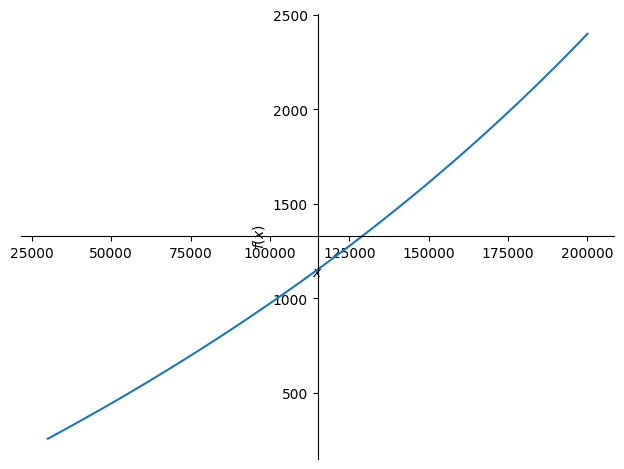

In [ ]:
sp.plot(1/cost.evalf(), (x, 30000, 200000))

In [91]:
1/cost.evalf().subs(x, 10000)

83.3012768672608